In [1]:
import cv2 as cv
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
import os

步骤1：相机内参标定

In [6]:
def fisher_calibrate_camera(images_folder, save_path=''):
    images_names = glob.glob(images_folder)
    
    try:
        os.makedirs(save_path)
    except:
        print("save_path 文件夹已创建")
    images = []
    for imname in images_names:
        im = cv.imread(imname, 1)
        images.append(im)
 
    print("Number of images: ", len(images))
    #criteria used by checkerboard pattern detector.
    #Change this if the code can't find the checkerboard
    # criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)
    # subpix_criteria = (cv2.TERM_CRITERIA_EPS+cv2.TERM_CRITERIA_MAX_ITER, 30, 0.1)
    calibration_flags = cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC+cv2.fisheye.CALIB_CHECK_COND+cv2.fisheye.CALIB_FIX_SKEW

    rows = 11 #number of checkerboard rows.
    columns = 8 #number of checkerboard columns.
    world_scaling = 20 #change this to the real world square size. Or not.
 
    #coordinates of squares in the checkerboard world space
    objp = np.zeros((rows*columns,3), dtype=np.float32)
    objp[:,:2] = np.mgrid[0:rows,0:columns].T.reshape(-1,2)
    objp = world_scaling* objp
 
    #frame dimensions. Frames should be the same size.
    width = images[0].shape[1]
    height = images[0].shape[0]
 
    #Pixel coordinates of checkerboards
    imgpoints = [] # 2d points in image plane.
 
    #coordinates of the checkerboard in checkerboard world space.
    objpoints = [] # 3d point in real world space
 
 
    for idx, frame in enumerate(images):

        # if np.random.rand(1) > 0.2:
        #     continue
        #find the checkerboard
        ret, corners = cv.findChessboardCorners(frame, (rows, columns), flags=cv.CALIB_CB_ADAPTIVE_THRESH+cv.CALIB_CB_NORMALIZE_IMAGE)
                      #flags = cv.CALIB_CB_ADAPTIVE_THRESH+cv.CALIB_CB_NORMALIZE_IMAGE+cv.CALIB_CB_FAST_CHECK)
     
        
        
        if ret == True:
            # print(images_names[idx])
            #Convolution size used to improve corner detection. Don't make this too large.
            conv_size = (3, 3)
            gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
            # 角点坐标亚像素优化 criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001) 表示满足任意条件就停止迭代 （30次迭代或者误差小于0.001）
            corners = cv.cornerSubPix(gray, corners, (3, 3), (-1, -1),
                                        (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001))
            
            #opencv can attempt to improve the checkerboard coordinates
            # corners = cv.cornerSubPix(gray, corners, conv_size, (-1, -1), criteria)
            cv.drawChessboardCorners(frame, (rows,columns), corners, ret)
            if save_path != '':

                cv.imwrite(os.path.join(save_path, os.path.basename(images_names[idx])), frame)
                cv.imshow('img', frame)
                cv.waitKey(500)
 
            objpoints.append(objp)
            imgpoints.append(corners)
    cv.destroyAllWindows()
 
 
    print("calibrate num:",len(imgpoints))
    N_OK = len(objpoints)
    K = np.eye(3, 3)
    # 畸变系数 D
    D = np.zeros((4, 1))
    rvecs = [np.zeros((1, 1, 3), dtype=np.float64) for i in range(N_OK)]
    tvecs = [np.zeros((1, 1, 3), dtype=np.float64) for i in range(N_OK)]
    rms, K, D, rvecs, tvecs = cv2.fisheye.calibrate(
        np.expand_dims(np.asarray(objpoints), -2),
        imgpoints,
        gray.shape[::-1],
        K,
        D,
        rvecs,
        tvecs,
        calibration_flags,
        (cv2.TERM_CRITERIA_EPS+cv2.TERM_CRITERIA_MAX_ITER, 50, 1e-6)
    )
    print('rms:', rms)
    # ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(objpoints, imgpoints, (width, height), None, None)
    # print('rmse:', ret)
    # print('camera matrix:\n', K)
    # print('distortion coeffs:', D)
    # print('Rs:\n', rvecs)
    # print('Ts:\n', tvecs)
    # 计算反投影误差
    # calculate the camera calibration error
    error = 0
    for i in range(len(objpoints)):
        imgPoints2, _ = cv2.fisheye.projectPoints(np.expand_dims(np.asarray(objpoints[i]), -2), rvecs[i], tvecs[i], K, D)
        error += cv2.norm(imgpoints[i], imgPoints2, cv2.NORM_L2) / len(imgPoints2)

    print("Total error: ", error / len(objpoints))
    # print('rmse:', mean_error)
    print('camera matrix:\n', K)
    print('distortion coeffs:', D)
    # print('Rs:\n', rvecs[0])
    # print('Ts:\n', tvecs[0])
    
    
    return K, D, rvecs, tvecs, objpoints, imgpoints

In [7]:
mtx1, dist1, rvecs1, tvecs1,objpoints, imgpoints = fisher_calibrate_camera(images_folder = './data/ImgDatas_Cam1_intrinsic/*', save_path = '')#'out/IR_Calibrate_dataset_Filter/ImgDatas_Cam1_intrinsic')
# np.savez("./Matrix_calibration/Cam1_Fisher_Intrinsic.npz", mtx = mtx1, dist=dist1)
mtx2, dist2, rvecs2, tvecs2,_,_ = fisher_calibrate_camera(images_folder = './data/ImgDatas_Cam2_intrinsic/*', save_path = '')#'out/IR_Calibrate_dataset_Filter/ImgDatas_Cam2_intrinsic')
# np.savez("./Matrix_calibration/Cam2_Fisher_Intrinsic.npz", mtx = mtx2, dist=dist2)

save_path 文件夹已创建
Number of images:  25
calibrate num: 25
rms: 0.7704620350954231
Total error:  0.08126455615373798
camera matrix:
 [[255.45281565   0.         318.73282595]
 [  0.         255.49287828 213.99523338]
 [  0.           0.           1.        ]]
distortion coeffs: [[ 0.38491242]
 [-0.02999069]
 [ 0.30499913]
 [-0.07743532]]
save_path 文件夹已创建
Number of images:  25
calibrate num: 25
rms: 0.4825075841926017
Total error:  0.050778174270876636
camera matrix:
 [[252.6549543    0.         299.80717205]
 [  0.         252.33957458 243.26770408]
 [  0.           0.           1.        ]]
distortion coeffs: [[ 0.3307871 ]
 [ 0.37726879]
 [-0.73421113]
 [ 0.85052657]]


步骤2：标定的内参检验

2.1 图像去畸变

In [10]:
# 自己实现的图像去畸变，和直接调用cv2.fisheye.undistortImage()效果一样
def undistort(img_path,K,D,DIM,scale=0,imshow=False):
    width, height = DIM
    img = cv2.imread(img_path)
    dim1 = img.shape[:2][::-1]  #dim1 is the dimension of input image to un-distort


    assert dim1[0]/dim1[1] == DIM[0]/DIM[1], "Image to undistort needs to have same aspect ratio as the ones used in calibration"
    # if not dim2:
    #     dim2 = dim1
    # if not dim3:
    #     dim3 = dim1
    scaled_K = K * dim1[0] / DIM[0]  # The values of K is to scale with image dimension.
    scaled_K[2][2] = 1.0  # Except that K[2][2] is always 1.0
    Knew = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(scaled_K, D, DIM, np.eye(3), balance=1)
    print(Knew)
    map1, map2 = cv2.fisheye.initUndistortRectifyMap(K, D, np.eye(3), Knew, DIM, cv2.CV_16SC2)
    undistorted_img = cv2.remap(img, map1, map2, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)
    
    #estimateNewCameraMatrixForUndistortRectify, initUndistortRectifyMap, remap加起来 和 undistortImage功能一样
    output = np.zeros((height, width*2, 3), dtype=np.uint8)
    output[0:img.shape[0], 0:img.shape[1]] = img
    output[0:undistorted_img.shape[0], undistorted_img.shape[1]:] = undistorted_img
    if imshow:
        plt.figure(figsize=(20,10))
        plt.subplot(1,2,1)
        plt.imshow(img)
        plt.title('Original Image')
        plt.axis('off')
        plt.subplot(1,2,2)
        plt.imshow(undistorted_img)
        plt.title('Undistorted Image')
        plt.axis('off')
        plt.show()
    return undistorted_img

[[257.79063272   0.         318.74757983]
 [  0.         257.831062   214.24735128]
 [  0.           0.           1.        ]]


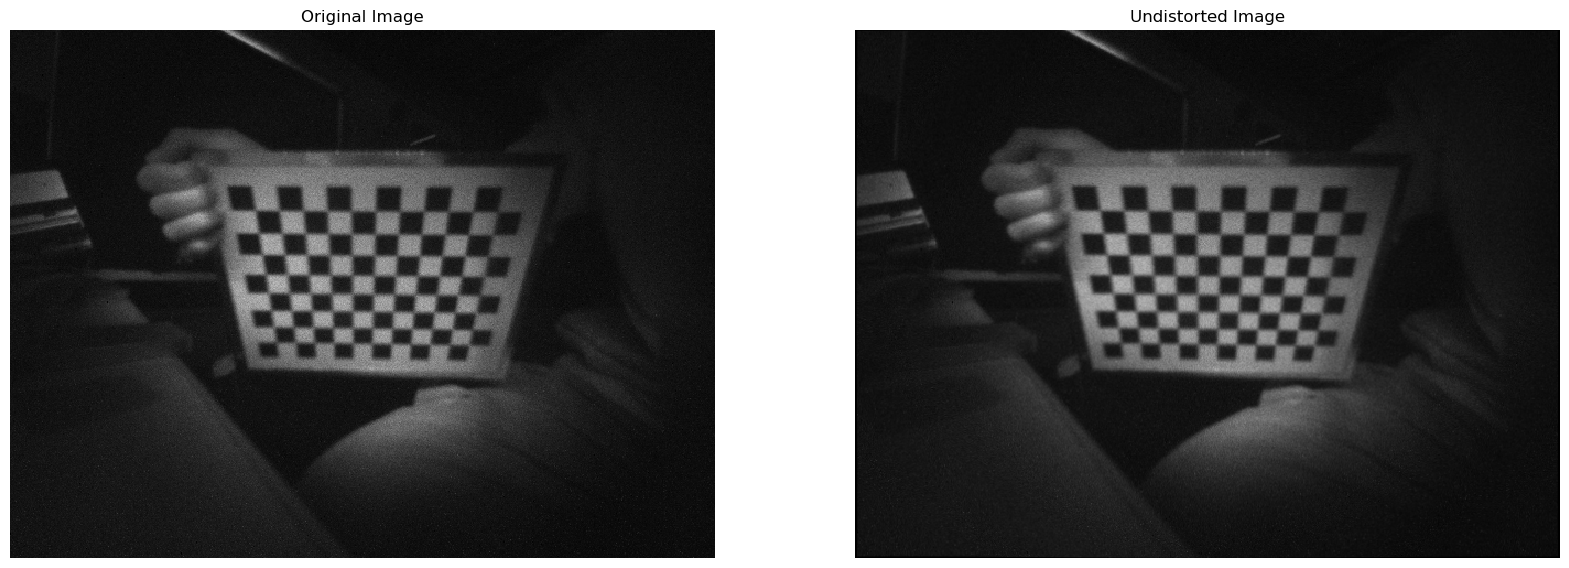

In [12]:
# Cam1_ins = np.load("Cam1_Fisher_Intrinsic.npz")
# left_cameraMatrix, left_distCoeffs = mtx1, dist1
# Cam2_ins = np.load("Cam2_Fisher_Intrinsic.npz")
# right_cameraMatrix, right_distCoeffs = mtx2, dist2

Cam3_ins = np.load("./Matrix_calibration/Cam1_Fisher_Intrinsic.npz")

mtx, dist = (Cam3_ins['mtx'], Cam3_ins['dist'])
DIM=(640, 480)
K=mtx
D=dist
# 查看去畸变效果
undistorted_img = undistort('.\data\ImgDatas_Cam1_intrinsic/2024_09_23_02_14_22_101_2_.png',K, D,DIM,scale=1, imshow=True)

检验矩形去畸变结果，验证内参标注准确度

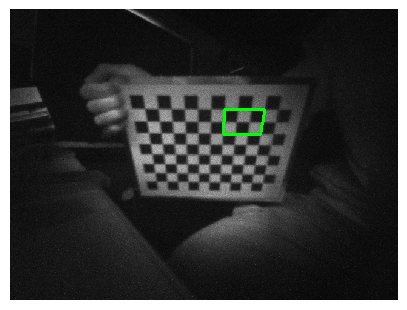

In [16]:
img_path = '.\data\ImgDatas_Cam1_intrinsic/2024_09_23_02_14_22_101_2_.png'
img = cv2.imread(img_path)
# 设置四个角点坐标，人为提取
box_tl = [354,165]
box_tr = [420,166]
box_dl = [351,206]
box_dr =  [413,206]
#RGB

pts = np.array([box_tl, box_tr, box_dr, box_dl], np.int32)  # 每个点都是(x, y)
pts = pts.reshape((-1,1,2))
draw_img = cv2.polylines(img.copy(),[pts],True,(0,255,0), 3)

plt.figure(figsize=(5, 5))
plt.imshow(draw_img)
plt.axis('off')
plt.show()


[[[353.91937 165.11201]]

 [[419.50702 166.23364]]

 [[412.6081  206.03323]]

 [[350.9738  206.0065 ]]]


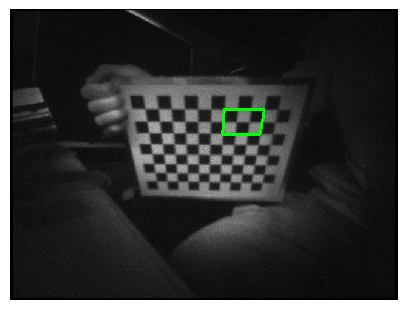

In [21]:
# cv2官方api提供的去畸变方法cv2.fisheye.undistortImage 和 cv2.fisheye.undistortPoints
undistorted_img = cv2.fisheye.undistortImage(distorted=img, K=K, D=D, Knew=K)
undistorted_ip = cv2.fisheye.undistortPoints(pts.astype(np.float32), K=K, D=D, P=K)

draw_undistort_img = cv2.polylines(undistorted_img.copy(),[undistorted_ip.astype(np.int32)],True,(0,255,0), 3)

print(undistorted_ip)
plt.figure(figsize=(5,5))
plt.imshow(draw_undistort_img)
plt.axis('off')
plt.show()

步骤3：相机cam_sup到屏幕外参标定

In [7]:
image_path = './IR_Calibrate_dataset_Filter\Cam1_CamSup\CamSup2Screen\WIN_20240527_18_08_52_Pro.jpg'
image = cv2.imread(image_path)
gray = cv.cvtColor(image.astype(np.uint8), cv.COLOR_BGR2GRAY)
rows = 11 #number of checkerboard rows.
columns = 7 #number of checkerboard columns.
world_scaling = 20. #change this to the real world square size. Or not.

#coordinates of squares in the checkerboard world space
objp = np.zeros((rows*columns,3), dtype=np.float32)
objp[:,:2] = np.mgrid[0:rows,0:columns].T.reshape(-1,2)
objp = world_scaling* objp

#frame dimensions. Frames should be the same size.
width = image.shape[1]
height = image.shape[0]

#Pixel coordinates of checkerboards
imgpoints = [] # 2d points in image plane.

#coordinates of the checkerboard in checkerboard world space.
objpoints = [] # 3d point in real world space
ret, corners = cv.findChessboardCorners(gray, (rows, columns),flags = cv.CALIB_CB_ADAPTIVE_THRESH|cv.CALIB_CB_NORMALIZE_IMAGE|cv.CALIB_CB_FAST_CHECK)
# gray = cv.cvtColor(gray, cv.COLOR_BGR2GRAY)
# 角点坐标亚像素优化
corners = cv.cornerSubPix(gray, corners, (3, 3), (-1, -1),
                            (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001))
objpoints.append(objp)
imgpoints.append(corners)
N_OK = len(objpoints)
K = np.load("Matrix_calibrate\Cam3_Fisher_Intrinsic.npz")['mtx']
D = np.load("Matrix_calibrate\Cam3_Fisher_Intrinsic.npz")['dist']

_, rvec, tvec = cv2.solvePnP(objpoints[0], imgpoints[0], K, D)  # 解算位姿
rvec_matrix = cv2.Rodrigues(rvec)[0]  # 旋转向量->旋转矩阵
distance = np.sqrt(tvec[0] ** 2 + tvec[1] ** 2 + tvec[2] ** 2)  # 计算  相机到目标物体的距离
np.savez("Matrix_calibrate/Cam3_to_Screen_Fisher_Extrinsic.npz", R = rvec_matrix, T=tvec)

[[137.05681   17.698872   0.      ]
 [239.53725   18.372711   0.      ]
 [238.5486    82.569084   0.      ]
 [136.64296   84.15449    0.      ]]


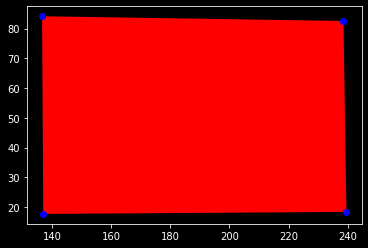

In [9]:
def camera2world(point2D, rVec, tVec, cameraMat, height):
    """
       Function used to convert given 2D points back to real-world 3D points
       point2D  : An array of 2D points
       rVec     : Rotation vector
       tVec     : Translation vector
       cameraMat: Camera Matrix used in solvePnP
       height   : Height in real-world 3D space
       Return   : output_array: Output array of 3D points

    """
    point3D = []
    point2D = (np.array(point2D, dtype='float32')).reshape(-1, 2)
    numPts = point2D.shape[0]
    point2D_op = np.hstack((point2D, np.ones((numPts, 1))))
    rMat = cv2.Rodrigues(rVec)[0]
    rMat_inv = np.linalg.inv(rMat)
    kMat_inv = np.linalg.inv(cameraMat)
    for point in range(numPts):
        uvPoint = point2D_op[point, :].reshape(3, 1)
        tempMat = np.matmul(rMat_inv, kMat_inv)
        tempMat1 = np.matmul(tempMat, uvPoint)
        tempMat2 = np.matmul(rMat_inv, tVec)
        s = (height + tempMat2[2]) / tempMat1[2]
        p = tempMat1 * s - tempMat2
        point3D.append(p)

    point3D = (np.array(point3D, dtype='float32')).reshape([-1, 1, 3])
    return point3D

pts_world = camera2world(undistort_pts, rvec, tvec, K, height=0).reshape(-1, 3)
print(pts_world)

x = pts_world[:, 0]  #构造横坐标数据
y = pts_world[:, 1]  #构造纵坐标数据
plt.plot(x, y, 'bo')
plt.fill(x, y, 'r')
plt.show()  # 可以看出，世界坐标系中的box基本是个矩形
